In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

import joblib


In [2]:
from google.colab import files

uploaded = files.upload()

Saving kaushal_konnect_training_data.csv to kaushal_konnect_training_data (1).csv


In [3]:
data = pd.read_csv("kaushal_konnect_training_data.csv")

display(data.head())

print("Dataset shape:", data.shape)

,worker_id,category,user_zone,worker_zone,available,weekly_gigs,rating,completed_jobs,acceptance_rate,cancellation_rate,response_minutes,price,budget,distance_km,successful_booking
0,58,Plumber,East,South,1,11,3.2,189,0.95,0.03,110,265,361,2.8,1
1,14,Electrician,West,South,1,4,4.6,1,0.88,0.05,110,896,869,4.3,0
2,173,Plumber,North,West,1,13,3.7,67,0.90,0.22,139,455,1075,2.4,0
3,186,Electrician,North,North,1,12,3.6,20,0.93,0.26,99,769,1228,16.1,0
4,190,Carpenter,South,East,1,10,4.3,155,0.82,0.16,64,534,1246,9.8,0


Dataset shape: (1000, 15)


In [4]:
expected_columns = [
    "worker_id",
    "category",
    "user_zone",
    "worker_zone",
    "available",
    "weekly_gigs",
    "rating",
    "completed_jobs",
    "acceptance_rate",
    "cancellation_rate",
    "response_minutes",
    "price",
    "budget",
    "distance_km",
    "successful_booking"
]

print("All required columns available:")
print(set(expected_columns).issubset(data.columns))

print("\nColumns in the CSV:")
print(data.columns.tolist())

All required columns available:
True

Columns in the CSV:
['worker_id', 'category', 'user_zone', 'worker_zone', 'available', 'weekly_gigs', 'rating', 'completed_jobs', 'acceptance_rate', 'cancellation_rate', 'response_minutes', 'price', 'budget', 'distance_km', 'successful_booking']


In [3]:

np.random.seed(42)

number_of_records = 1000

categories = ["Plumber", "Electrician", "Carpenter", "Mechanic"]
zones = ["North", "South", "East", "West"]

data = pd.DataFrame({
    "worker_id": range(1, number_of_records + 1),

    "category": np.random.choice(categories, number_of_records),

    "user_zone": np.random.choice(zones, number_of_records),

    "worker_zone": np.random.choice(zones, number_of_records),

    "available": np.random.choice([0, 1], number_of_records, p=[0.15, 0.85]),

    "weekly_gigs": np.random.randint(0, 15, number_of_records),

    "rating": np.round(np.random.uniform(3.0, 5.0, number_of_records), 1),

    "completed_jobs": np.random.randint(0, 200, number_of_records),

    "acceptance_rate": np.round(
        np.random.uniform(0.50, 1.00, number_of_records), 2
    ),

    "cancellation_rate": np.round(
        np.random.uniform(0.00, 0.30, number_of_records), 2
    ),

    "response_minutes": np.random.randint(2, 180, number_of_records),

    "price": np.random.randint(200, 1500, number_of_records),

    "budget": np.random.randint(300, 1600, number_of_records),

    "distance_km": np.round(
        np.random.uniform(0.5, 25.0, number_of_records), 1
    )
})

data.head()

,worker_id,category,user_zone,worker_zone,available,weekly_gigs,rating,completed_jobs,acceptance_rate,cancellation_rate,response_minutes,price,budget,distance_km
0,1,Carpenter,South,East,1,2,4.6,43,0.91,0.09,44,843,1301,20.2
1,2,Mechanic,East,West,1,14,4.2,33,0.84,0.23,155,535,606,1.0
2,3,Plumber,North,South,0,14,5.0,76,0.82,0.19,72,1121,565,20.9
3,4,Carpenter,North,West,1,14,3.7,41,0.70,0.02,167,346,945,4.0
4,5,Carpenter,North,West,1,3,4.9,136,0.79,0.15,95,321,617,24.4


In [4]:
same_zone = (data["user_zone"] == data["worker_zone"]).astype(int)

extra_price = np.maximum(data["price"] - data["budget"], 0)

success_score = (
    -1.5
    + 1.2 * (data["rating"] - 4)
    + 0.008 * data["completed_jobs"]
    + 1.2 * data["acceptance_rate"]
    - 2.0 * data["cancellation_rate"]
    - 0.01 * data["response_minutes"]
    - 0.04 * data["distance_km"]
    - 0.0015 * extra_price
    + 0.8 * data["available"]
    + 0.4 * same_zone
)

booking_probability = 1 / (1 + np.exp(-success_score))

data["successful_booking"] = np.random.binomial(
    1,
    booking_probability
)

data[["worker_id", "rating", "weekly_gigs", "available", "successful_booking"]].head()

,worker_id,rating,weekly_gigs,available,successful_booking
0,1,4.6,2,1,0
1,2,4.2,14,1,0
2,3,5.0,14,0,0
3,4,3.7,14,1,0
4,5,4.9,3,1,0


In [5]:
data.info()

print("\nMissing values in each column:\n")
print(data.isnull().sum())

print("\nStatistical summary:\n")
display(data.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   worker_id           1000 non-null   int64  
 1   category            1000 non-null   object 
 2   user_zone           1000 non-null   object 
 3   worker_zone         1000 non-null   object 
 4   available           1000 non-null   int64  
 5   weekly_gigs         1000 non-null   int64  
 6   rating              1000 non-null   float64
 7   completed_jobs      1000 non-null   int64  
 8   acceptance_rate     1000 non-null   float64
 9   cancellation_rate   1000 non-null   float64
 10  response_minutes    1000 non-null   int64  
 11  price               1000 non-null   int64  
 12  budget              1000 non-null   int64  
 13  distance_km         1000 non-null   float64
 14  successful_booking  1000 non-null   int64  
dtypes: float64(4), int64(8), object(3)
memory usage: 117.3+ 

,worker_id,available,weekly_gigs,rating,completed_jobs,acceptance_rate,cancellation_rate,response_minutes,price,budget,distance_km,successful_booking
count,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,152.012000,0.833000,7.007000,4.00220,100.718000,0.746670,0.151680,93.299000,856.797000,949.373000,12.819000,0.304000
std,86.428929,0.373162,4.242989,0.57514,57.697014,0.143253,0.087396,50.099417,374.352654,368.541654,7.062599,0.460213
min,1.000000,0.000000,0.000000,3.00000,0.000000,0.500000,0.000000,2.000000,200.000000,301.000000,0.500000,0.000000
25%,77.000000,1.000000,3.000000,3.50000,52.000000,0.620000,0.070000,51.000000,531.250000,633.250000,6.600000,0.000000
50%,154.000000,1.000000,7.000000,4.00000,98.000000,0.750000,0.150000,96.000000,861.500000,936.000000,12.900000,0.000000
75%,226.000000,1.000000,11.000000,4.50000,149.250000,0.870000,0.230000,136.000000,1174.000000,1254.000000,19.100000,1.000000
max,300.000000,1.000000,14.000000,5.00000,199.000000,1.000000,0.300000,180.000000,1500.000000,1600.000000,25.000000,1.000000


In [6]:
features = [
    "category",
    "available",
    "weekly_gigs",
    "rating",
    "completed_jobs",
    "acceptance_rate",
    "cancellation_rate",
    "response_minutes",
    "price",
    "budget",
    "distance_km"
]

target = "successful_booking"

X = data[features]

y = data[target]

print("Feature data shape:", X.shape)
print("Target data shape:", y.shape)

display(X.head())

print("\nTarget values:")
print(y.value_counts())

Feature data shape: (1000, 11)
Target data shape: (1000,)


,category,available,weekly_gigs,rating,completed_jobs,acceptance_rate,cancellation_rate,response_minutes,price,budget,distance_km
0,Plumber,1,11,3.2,189,0.95,0.03,110,265,361,2.8
1,Electrician,1,4,4.6,1,0.88,0.05,110,896,869,4.3
2,Plumber,1,13,3.7,67,0.90,0.22,139,455,1075,2.4
3,Electrician,1,12,3.6,20,0.93,0.26,99,769,1228,16.1
4,Carpenter,1,10,4.3,155,0.82,0.16,64,534,1246,9.8



Target values:
successful_booking
0    696
1    304
Name: count, dtype: int64


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training feature data shape:", X_train.shape)
print("Testing feature data shape:", X_test.shape)

print("\nTraining target values:")
print(y_train.value_counts())

print("\nTesting target values:")
print(y_test.value_counts())

Training feature data shape: (800, 11)
Testing feature data shape: (200, 11)

Training target values:
successful_booking
0    557
1    243
Name: count, dtype: int64

Testing target values:
successful_booking
0    139
1     61
Name: count, dtype: int64


In [8]:
categorical_features = [
    "category"
]

numerical_features = [
    "available",
    "weekly_gigs",
    "rating",
    "completed_jobs",
    "acceptance_rate",
    "cancellation_rate",
    "response_minutes",
    "price",
    "budget",
    "distance_km"
]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "category_encoder",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        ),
        (
            "numerical_scaler",
            StandardScaler(),
            numerical_features
        )
    ]
)

print("Data preprocessing pipeline created successfully.")

Data preprocessing pipeline created successfully.


In [9]:
recommendation_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            LogisticRegression(
                max_iter=1000,
                class_weight="balanced",
                random_state=42
            )
        )
    ]
)

recommendation_model.fit(X_train, y_train)

print("Model training completed successfully.")

Model training completed successfully.


In [10]:
y_pred = recommendation_model.predict(X_test)

y_probability = recommendation_model.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred)

roc_auc = roc_auc_score(y_test, y_probability)

print("Accuracy:", round(accuracy, 3))
print("ROC-AUC Score:", round(roc_auc, 3))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.705
ROC-AUC Score: 0.758

Classification Report:

              precision    recall  f1-score   support

           0       0.87      0.68      0.76       139
           1       0.51      0.77      0.61        61

    accuracy                           0.70       200
   macro avg       0.69      0.72      0.69       200
weighted avg       0.76      0.70      0.72       200



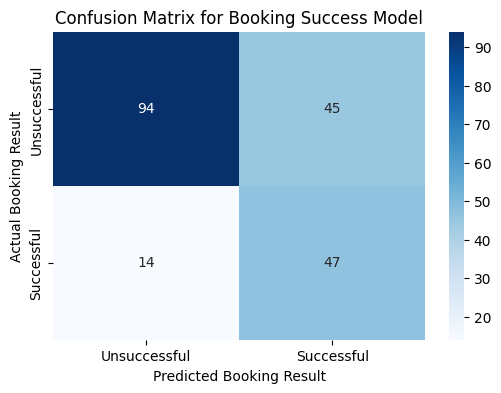

In [11]:
matrix = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))

sns.heatmap(
    matrix,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Unsuccessful", "Successful"],
    yticklabels=["Unsuccessful", "Successful"]
)

plt.xlabel("Predicted Booking Result")
plt.ylabel("Actual Booking Result")
plt.title("Confusion Matrix for Booking Success Model")

plt.show()

In [12]:
customer_request = {
    "category": "Plumber",
    "zone": "North",
    "budget": 900
}

eligible_workers = data[
    (data["category"] == customer_request["category"])
    & (data["worker_zone"] == customer_request["zone"])
    & (data["available"] == 1)
].copy()

eligible_workers["budget"] = customer_request["budget"]

eligible_workers["booking_success_probability"] = (
    recommendation_model.predict_proba(eligible_workers[features])[:, 1]
)

maximum_weekly_gigs = max(eligible_workers["weekly_gigs"].max(), 1)

eligible_workers["workload_balance_score"] = (
    1 - eligible_workers["weekly_gigs"] / maximum_weekly_gigs
)

eligible_workers["recommendation_score"] = (
    0.85 * eligible_workers["booking_success_probability"]
    + 0.15 * eligible_workers["workload_balance_score"]
)

recommended_workers = eligible_workers.sort_values(
    by="recommendation_score",
    ascending=False
)

display(
    recommended_workers[
        [
            "worker_id",
            "category",
            "worker_zone",
            "rating",
            "weekly_gigs",
            "price",
            "distance_km",
            "booking_success_probability",
            "workload_balance_score",
            "recommendation_score"
        ]
    ].head(10)
)

,worker_id,category,worker_zone,rating,weekly_gigs,price,distance_km,booking_success_probability,workload_balance_score,recommendation_score
65,117,Plumber,North,4.7,11,294,20.0,0.804799,0.214286,0.716222
445,183,Plumber,North,4.2,3,246,13.7,0.673331,0.785714,0.690188
85,286,Plumber,North,4.5,11,1359,2.2,0.729210,0.214286,0.651971
165,72,Plumber,North,4.7,3,1012,1.2,0.617335,0.785714,0.642592
7,253,Plumber,North,4.6,2,1158,6.7,0.574896,0.857143,0.617233
452,244,Plumber,North,4.2,2,931,1.8,0.574729,0.857143,0.617091
396,184,Plumber,North,4.2,11,1091,5.7,0.666930,0.214286,0.599033
700,48,Plumber,North,3.3,9,1371,1.1,0.632902,0.357143,0.591538
713,9,Plumber,North,4.4,6,1339,12.6,0.592063,0.571429,0.588968
203,23,Plumber,North,4.8,6,1058,8.4,0.545298,0.571429,0.549218


In [13]:
model_file_name = "kaushal_konnect_recommendation_model.joblib"

joblib.dump(recommendation_model, model_file_name)

print(f"Model saved successfully as: {model_file_name}")

Model saved successfully as: kaushal_konnect_recommendation_model.joblib


In [14]:
from google.colab import files
files.download("kaushal_konnect_recommendation_model.joblib")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [17]:
def get_recommendations(category, zone, budget, worker_data, top_n=10):
    eligible_workers = worker_data[
        (worker_data["category"] == category)
        & (worker_data["worker_zone"] == zone)
        & (worker_data["available"] == 1)
    ].copy()

    if eligible_workers.empty:
        return pd.DataFrame()

    eligible_workers["budget"] = budget

    eligible_workers["booking_success_probability"] = (
        recommendation_model.predict_proba(eligible_workers[features])[:, 1]
    )

    maximum_weekly_gigs = max(eligible_workers["weekly_gigs"].max(), 1)

    eligible_workers["workload_balance_score"] = (
        1 - eligible_workers["weekly_gigs"] / maximum_weekly_gigs
    )

    eligible_workers["recommendation_score"] = (
        0.85 * eligible_workers["booking_success_probability"]
        + 0.15 * eligible_workers["workload_balance_score"]
    )

    recommended_workers = eligible_workers.sort_values(
        by="recommendation_score",
        ascending=False
    )

    return recommended_workers.head(top_n)

In [18]:
final_recommendations = get_recommendations(
    category="Plumber",
    zone="North",
    budget=900,
    worker_data=data,
    top_n=10
)

final_recommendations = final_recommendations.sort_values(
    by="recommendation_score",
    ascending=False
).reset_index(drop=True)

final_recommendations.insert(
    0,
    "rank",
    range(1, len(final_recommendations) + 1)
)

display(
    final_recommendations[
        [
            "rank",
            "worker_id",
            "category",
            "worker_zone",
            "rating",
            "weekly_gigs",
            "price",
            "booking_success_probability",
            "workload_balance_score",
            "recommendation_score"
        ]
    ]
)

,rank,worker_id,category,worker_zone,rating,weekly_gigs,price,booking_success_probability,workload_balance_score,recommendation_score
0,1,654,Plumber,North,4.7,1,825,0.927000,0.928571,0.927236
1,2,218,Plumber,North,4.2,0,680,0.821674,1.000000,0.848423
2,3,573,Plumber,North,4.7,10,1044,0.931821,0.285714,0.834905
3,4,495,Plumber,North,4.1,3,378,0.817117,0.785714,0.812407
4,5,483,Plumber,North,4.3,5,535,0.815812,0.642857,0.789869
5,6,934,Plumber,North,4.6,14,407,0.871851,0.000000,0.741074
6,7,967,Plumber,North,4.4,0,218,0.689464,1.000000,0.736044
7,8,886,Plumber,North,3.4,0,707,0.664829,1.000000,0.715105
8,9,469,Plumber,North,4.6,7,1188,0.743567,0.500000,0.707032
9,10,261,Plumber,North,4.0,0,832,0.653093,1.000000,0.705129
